# How much do the embedding spaces agree?

For a large random sample of (clue, board word) pairs, plot each pair of
embedding spaces against each other. One point = one (clue, board word)
pair; its x/y are that pair's cosine similarity in two different spaces.

Context: `docs/versions/z_threshold.md` measured the `z_threshold`
baseline at 0% assassin-hit against a guesser using its own space
(numberbatch) but 29-38% against guessers using the other two. The
explanation offered was that the spaces disagree enough that a word which
is far from a clue in one space can be close to it in another. These
plots are the direct look at that claim.

Requires `cache/similarity_tensor.npy` (`scripts/data/build_similarity_tensor.py`).

In [1]:
import sys
from pathlib import Path

# Notebook lives in scratch/, one level below the project root.
PROJECT_ROOT = Path.cwd().parent if (Path.cwd().parent / "codenames").exists() else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import itertools

import numpy as np
import matplotlib.pyplot as plt

from codenames.similarity import SimilarityTensor

In [2]:
N_CLUES = 4000      # sampled clue rows; x400 board words each
N_PLOT = 40_000     # points actually drawn (scatter overplots badly above this)
SEED = 0
OUT_DIR = Path("/tmp/claude-1000/-home-maste-CodenamesAI/a7337e7d-b652-421c-aab9-1692ea201665/scratchpad")

In [3]:
sims = SimilarityTensor.load()
rng = np.random.default_rng(SEED)

# Sample whole clue rows rather than scattered (clue, word) cells: the
# tensor is memory-mapped, so row access is far cheaper than random access,
# and every sampled clue still contributes all 400 board words.
clue_idx = np.sort(rng.choice(len(sims.clue_words), size=N_CLUES, replace=False))
block = np.asarray(sims.tensor[clue_idx, :, :], dtype=np.float32)  # (N_CLUES, 400, n_spaces)

flat = block.reshape(-1, block.shape[2])  # one row per (clue, board word) pair
print(f"{flat.shape[0]:,} (clue, board word) pairs across {len(sims.spaces)} spaces: {sims.spaces}")
print(f"NaNs per space: {[int(np.isnan(flat[:, i]).sum()) for i in range(flat.shape[1])]}")

1,600,000 (clue, board word) pairs across 3 spaces: ['glove', 'numberbatch', 'wikipedia2vec']
NaNs per space: [0, 0, 0]


In [4]:
# The spymaster thresholds operate on per-clue z-scores, not raw cosine, so
# report agreement both ways: raw answers "do the spaces give similar
# numbers", z-scored answers "do they rank a clue's board words similarly",
# which is what actually decides whether a listener picks the assassin.
mu = block.mean(axis=1, keepdims=True)
sd = block.std(axis=1, keepdims=True)
zflat = ((block - mu) / sd).reshape(-1, block.shape[2])

pairs = list(itertools.combinations(range(len(sims.spaces)), 2))
for i, j in pairs:
    r_raw = np.corrcoef(flat[:, i], flat[:, j])[0, 1]
    r_z = np.corrcoef(zflat[:, i], zflat[:, j])[0, 1]
    print(f"{sims.spaces[i]:>14s} vs {sims.spaces[j]:<14s}  raw r={r_raw:.3f}   z-scored r={r_z:.3f}")

         glove vs numberbatch     raw r=0.336   z-scored r=0.337
         glove vs wikipedia2vec   raw r=0.429   z-scored r=0.425
   numberbatch vs wikipedia2vec   raw r=0.464   z-scored r=0.450


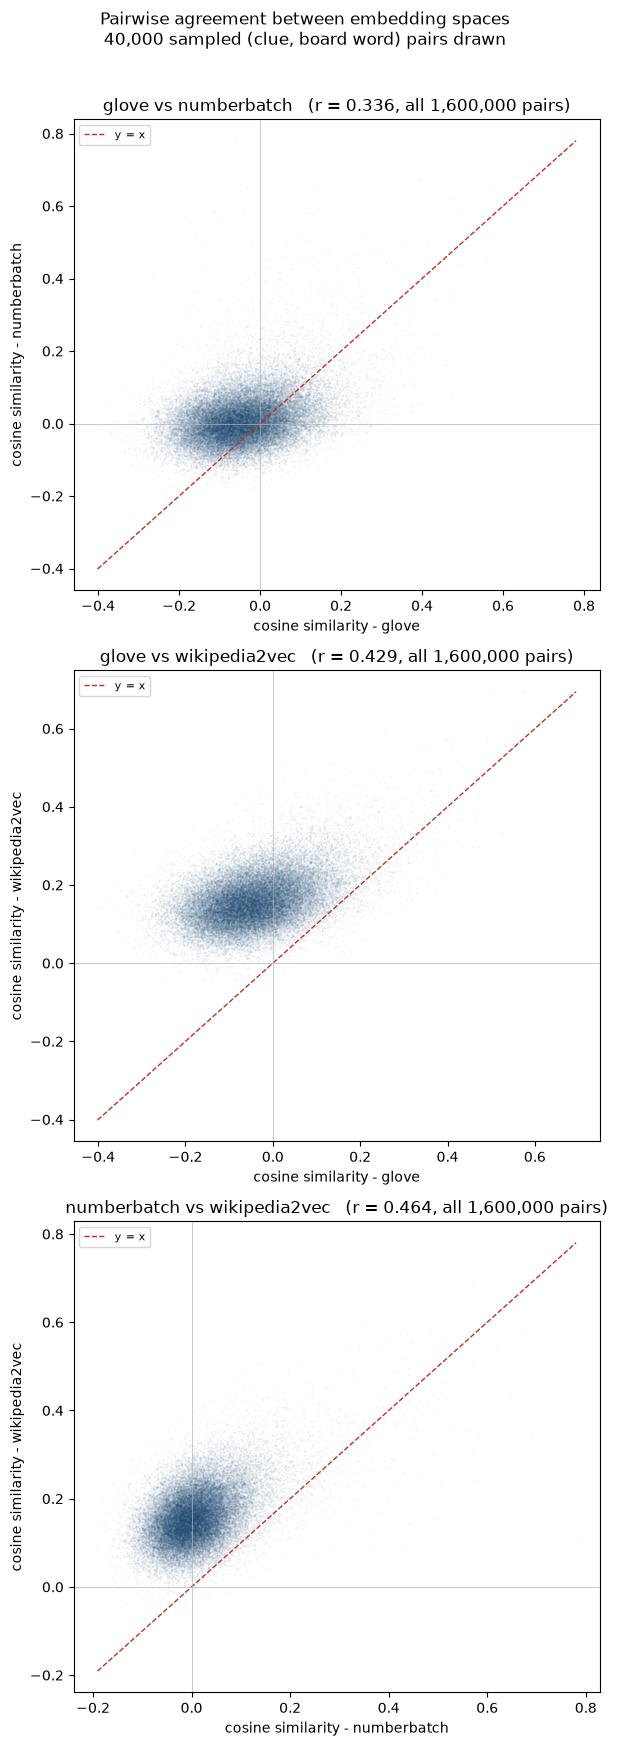

In [5]:
plot_rows = rng.choice(flat.shape[0], size=min(N_PLOT, flat.shape[0]), replace=False)

# Stacked vertically rather than side by side -- easier to read on a phone.
fig, axes = plt.subplots(len(pairs), 1, figsize=(6.2, 17.5))
for ax, (i, j) in zip(axes, pairs):
    x = flat[plot_rows, i]
    y = flat[plot_rows, j]
    ax.scatter(x, y, s=2, alpha=0.06, edgecolors="none", color="#1f4e79")
    lo = float(min(x.min(), y.min()))
    hi = float(max(x.max(), y.max()))
    ax.plot([lo, hi], [lo, hi], lw=1, ls="--", color="#c03020", label="y = x")
    r = np.corrcoef(flat[:, i], flat[:, j])[0, 1]
    ax.set_xlabel(f"cosine similarity - {sims.spaces[i]}")
    ax.set_ylabel(f"cosine similarity - {sims.spaces[j]}")
    ax.set_title(f"{sims.spaces[i]} vs {sims.spaces[j]}   (r = {r:.3f}, all {flat.shape[0]:,} pairs)")
    ax.axhline(0, lw=0.5, color="0.7")
    ax.axvline(0, lw=0.5, color="0.7")
    ax.legend(loc="upper left", fontsize=8)
fig.suptitle(f"Pairwise agreement between embedding spaces\n{len(plot_rows):,} sampled (clue, board word) pairs drawn", y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.985))
fig.savefig(OUT_DIR / "space_agreement_raw.png", dpi=125, bbox_inches="tight")
plt.show()

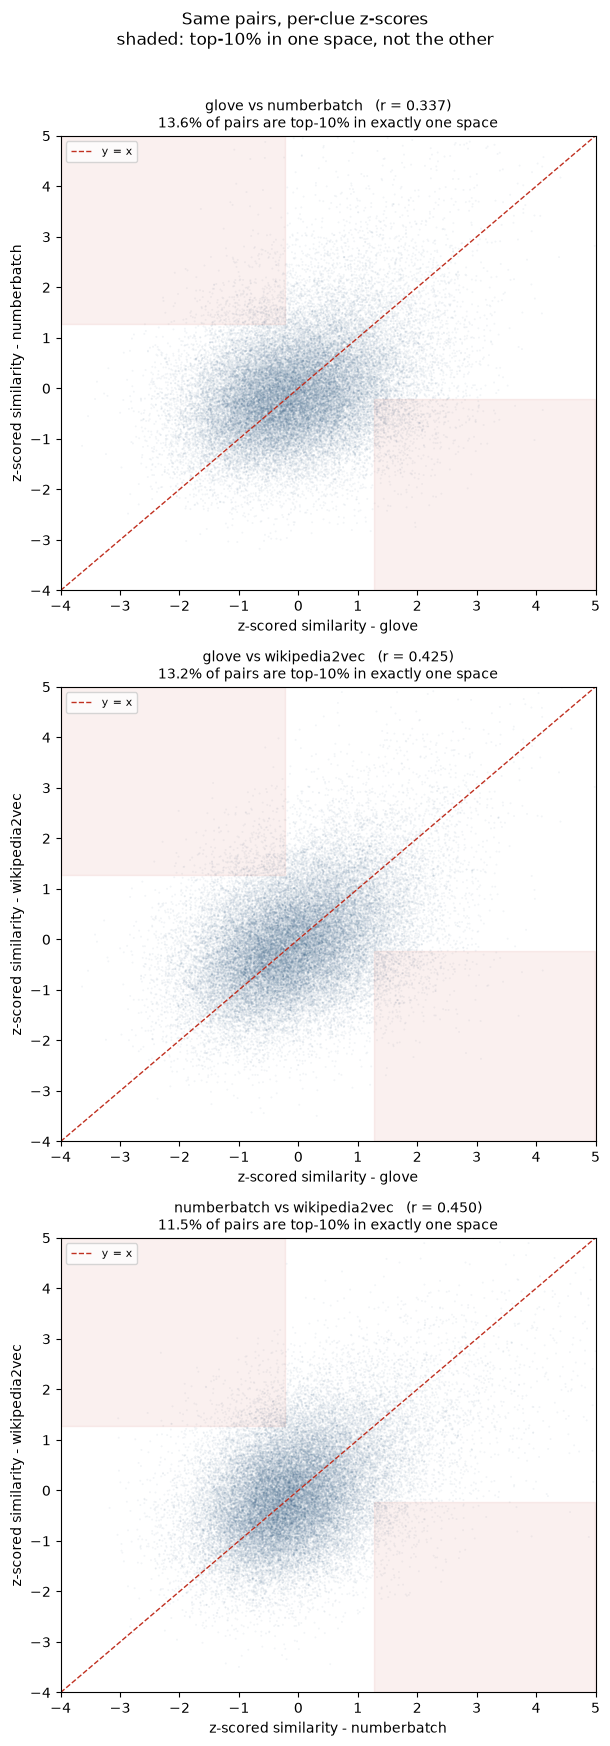

In [6]:
# Same three panels on per-clue z-scores. This is the view that matters for
# the baseline: a point far right and low means "one space thinks this board
# word is among the clue's closest, the other thinks it is unrelated" --
# exactly the case that lets an assassin be safe in one space and dangerous
# in another. Shaded quadrants mark those disagreements.
fig, axes = plt.subplots(len(pairs), 1, figsize=(6.2, 17.5))
for ax, (i, j) in zip(axes, pairs):
    x = zflat[plot_rows, i]
    y = zflat[plot_rows, j]
    ax.scatter(x, y, s=2, alpha=0.06, edgecolors="none", color="#1f4e79")
    ax.plot([-4, 5], [-4, 5], lw=1, ls="--", color="#c03020", label="y = x")
    ax.axvspan(1.28, 5, ymin=0, ymax=0.42, color="#c03020", alpha=0.07)
    ax.axhspan(1.28, 5, xmin=0, xmax=0.42, color="#c03020", alpha=0.07)
    r = np.corrcoef(zflat[:, i], zflat[:, j])[0, 1]
    disagree = float(np.mean((zflat[:, i] > 1.28) != (zflat[:, j] > 1.28)))
    ax.set_xlim(-4, 5)
    ax.set_ylim(-4, 5)
    ax.set_xlabel(f"z-scored similarity - {sims.spaces[i]}")
    ax.set_ylabel(f"z-scored similarity - {sims.spaces[j]}")
    ax.set_title(f"{sims.spaces[i]} vs {sims.spaces[j]}   (r = {r:.3f})\n"
                 f"{disagree:.1%} of pairs are top-10% in exactly one space", fontsize=10)
    ax.legend(loc="upper left", fontsize=8)
fig.suptitle("Same pairs, per-clue z-scores\nshaded: top-10% in one space, not the other", y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.985))
fig.savefig(OUT_DIR / "space_agreement_z.png", dpi=125, bbox_inches="tight")
plt.show()